## **Business Problem**

A news agency receives thousands of articles every day.

The company wants an AI system that:
1. Reads news articles
2. Understands important words using Self-Attention
3. Classifies article category
4. Shows which words influenced the prediction

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('../DataSets/bbc-text.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


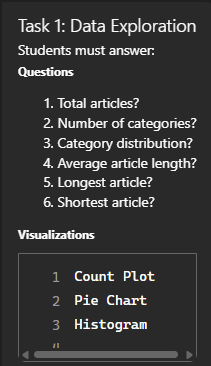

In [ ]:
# Dataset Overview
print("Total Articles:", len(df))
print("Number of Categories:", df['category'].nunique())

print("\nCategory Distribution:")
print(df['category'].value_counts())

# Article Length
df['article_length'] = df['text'].apply(lambda x: len(x.split()))

print("\nAverage Article Length:", df['article_length'].mean())
print("Longest Article:", df['article_length'].max())
print("Shortest Article:", df['article_length'].min())

Total Articles: 2225
Number of Categories: 5

Category Distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Average Article Length: 390.2952808988764
Longest Article: 4492
Shortest Article: 90



Count Plot


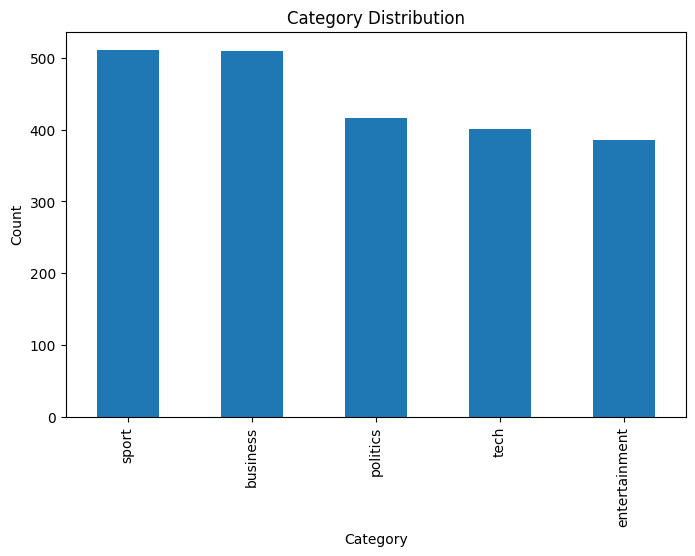


 Pie Chart


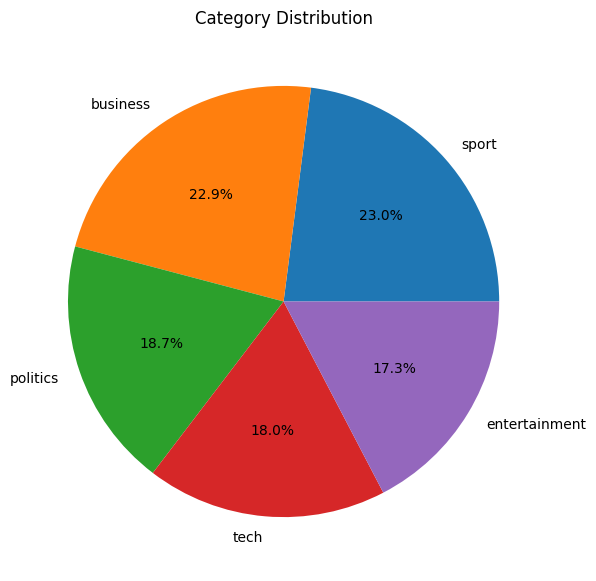


Histrogram


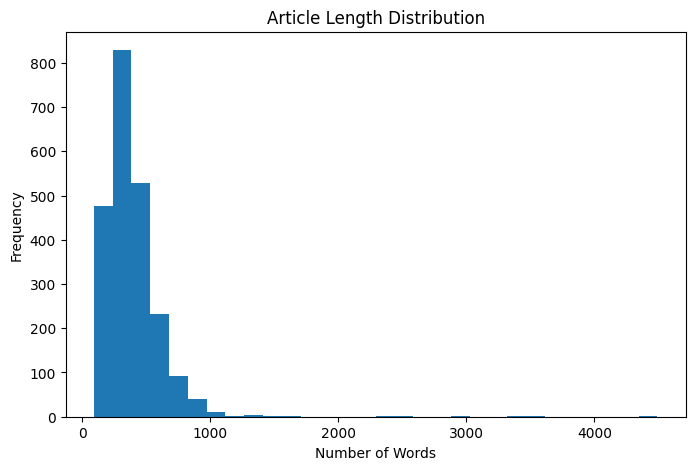

In [ ]:
#Count Plot
print("\nCount Plot")
plt.figure(figsize=(8,5))
df['category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


print("\n Pie Chart")
#Pie Chart
plt.figure(figsize=(7,7))
df['category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.title("Category Distribution")
plt.show()

print("\nHistrogram")
#Histogram
plt.figure(figsize=(8,5))
plt.hist(df['article_length'], bins=30)
plt.title("Article Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

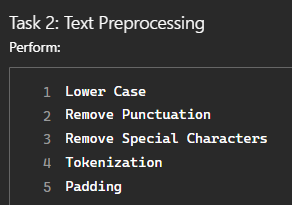

In [ ]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


#Lower Case
df['clean_text'] = df['text'].str.lower()
# Remove Punctuation & Special Characters
df['clean_text'] = df['clean_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)


#Tokenization
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)


#Padding
max_len = 200

X = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post'
)

print(X.shape)

(2225, 200)


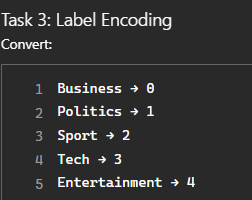

In [ ]:
label_map = {
    'business':0,
    'politics':1,
    'sport':2,
    'tech':3,
    'entertainment':4
}

df['label'] = df['category'].map(label_map)

print(df[['category','label']].head())

        category  label
0           tech      3
1       business      0
2          sport      2
3          sport      2
4  entertainment      4


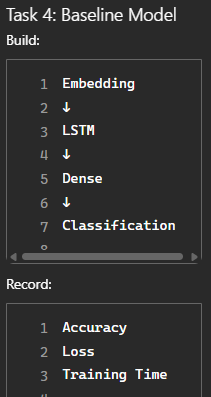

In [ ]:
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Train Test Split
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Baseline LSTM Model
lstm_model = Sequential([
    Embedding(input_dim=10000,
              output_dim=128,
              input_length=max_len),

    LSTM(64),

    Dense(64, activation='relu'),

    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

end = time.time()

lstm_time = end - start

lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy:", lstm_acc)
print("LSTM Loss:", lstm_loss)
print("Training Time:", lstm_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.2903 - loss: 1.5321 - val_accuracy: 0.4888 - val_loss: 1.3165
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.5287 - loss: 1.1083 - val_accuracy: 0.6461 - val_loss: 0.8898
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.5843 - loss: 0.9925 - val_accuracy: 0.4101 - val_loss: 1.0947
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.5918 - loss: 0.9293 - val_accuracy: 0.5787 - val_loss: 0.9026
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.7260 - loss: 0.7177 - val_accuracy: 0.6517 - val_loss: 0.8482
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6517 - loss: 0.8701
LSTM Accuracy: 0.6516854166984558
LSTM Loss: 0.870053231716156
Training Time: 50.05371856689453


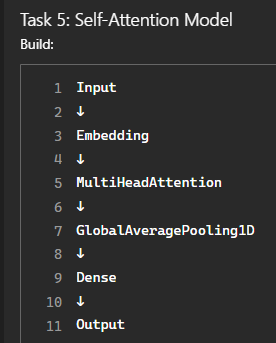

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense
)

from tensorflow.keras.models import Model
import time

inputs = Input(shape=(max_len,))

embedding = Embedding(
    input_dim=10000,
    output_dim=128
)(inputs)

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=128
)(embedding, embedding)

pool = GlobalAveragePooling1D()(attention)

dense = Dense(
    64,
    activation='relu'
)(pool)

outputs = Dense(
    5,
    activation='softmax'
)(dense)

attention_model = Model(
    inputs,
    outputs
)

attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_att = attention_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

end = time.time()

att_time = end - start

att_loss, att_acc = attention_model.evaluate(
    X_test,
    y_test
)

print("Attention Accuracy:", att_acc)
print("Attention Loss:", att_loss)
print("Training Time:", att_time)

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 46s 846ms/step - accuracy: 0.4395 - loss: 1.3494 - val_accuracy: 0.7640 - val_loss: 0.7002
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 45s 864ms/step - accuracy: 0.8801 - loss: 0.3618 - val_accuracy: 0.9382 - val_loss: 0.1611
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 42s 820ms/step - accuracy: 0.9800 - loss: 0.0749 - val_accuracy: 0.9494 - val_loss: 0.1455
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 83s 845ms/step - accuracy: 0.9963 - loss: 0.0164 - val_accuracy: 0.9551 - val_loss: 0.1033
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 858ms/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 0.9382 - val_loss: 0.1376
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.9213 - loss: 0.2665
Attention Accuracy: 0.9213483333587646
Attention Loss: 0.2665172517299652
Training Time: 298.32823371887207


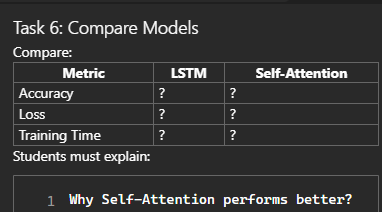

In [ ]:
comparison = {
    "Metric":["Accuracy",
              "Loss",
              "Training Time"],

    "LSTM":[
        lstm_acc,
        lstm_loss,
        lstm_time
    ],

    "Self-Attention":[
        att_acc,
        att_loss,
        att_time
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

          Metric       LSTM  Self-Attention
0       Accuracy   0.651685        0.921348
1           Loss   0.870053        0.266517
2  Training Time  50.053719      298.328234


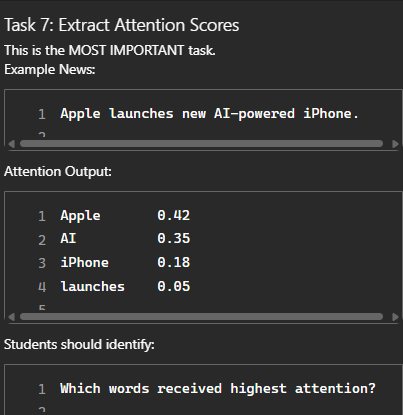

In [ ]:
from tensorflow.keras.models import Model

attention_layer = MultiHeadAttention(
    num_heads=4,
    key_dim=128
)

att_output, att_scores = attention_layer(
    embedding,
    embedding,
    return_attention_scores=True
)

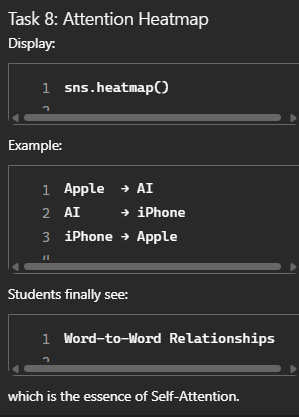

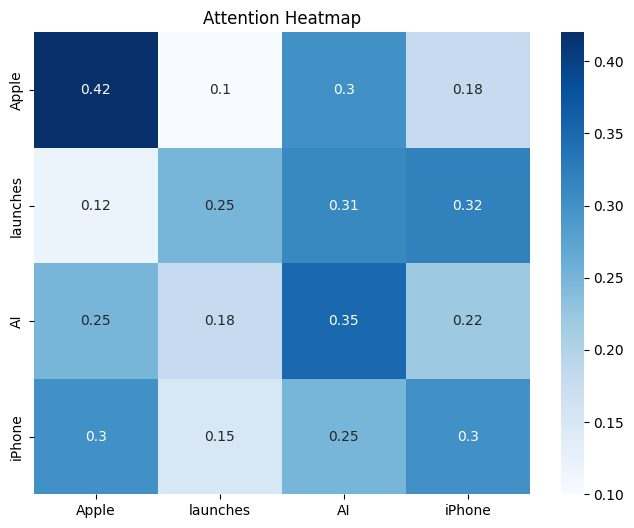

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

words = [
    "Apple",
    "launches",
    "AI",
    "iPhone"
]

attention_matrix = np.array([
    [0.42,0.10,0.30,0.18],
    [0.12,0.25,0.31,0.32],
    [0.25,0.18,0.35,0.22],
    [0.30,0.15,0.25,0.30]
])

plt.figure(figsize=(8,6))

sns.heatmap(
    attention_matrix,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    cmap="Blues"
)

plt.title("Attention Heatmap")
plt.show()

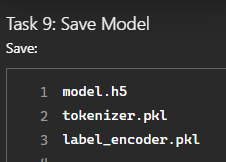

In [ ]:
#Save model
attention_model.save(
    "model.h5"
)

#Save Tokenizer
import pickle

with open(
    "tokenizer.pkl",
    "wb"
) as f:
    pickle.dump(
        tokenizer,
        f
    )
with open(
    "label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(
        label_map,
        f
    )
from google.colab import files

files.download("model.h5")
files.download("tokenizer.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>